# Skill Memory vs. OCL Survey strategies

This notebook runs the selected OCL Survey strategies from scratch for the same configurable seed set, then compares the resulting runs using the repository post-processing utilities.

Set `N_SEEDS` and `SELECTED_STRATEGIES` in the public configuration below. Every selected strategy is run for every selected seed before results are loaded.


## 0. Setup, public configuration, and fresh experiments

Edit `N_SEEDS` and `SELECTED_STRATEGIES` below to control the comparison. By default, all selected strategies are executed fresh before the results are loaded.


In [3]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/kobros-tech/ocl_survey.git"
REPO_REF = "feature/skill-memory-comparison-notebook"
COLAB_ROOT = Path("/content/ocl_survey")

# Public experiment controls.
N_SEEDS = 5
SEEDS = list(range(N_SEEDS))
RUN_EXPERIMENTS = True

AVAILABLE_STRATEGIES = {
    "Skill Memory": "skill_memory",
    "ER": "er",
    "ER-ACE": "er_ace",
    "DER++": "der",
    "MIR": "mir",
    "ER + LwF": "er_lwf",
    "RAR": "rar",
    "SCR": "scr",
    "AGEM": "agem",
    "MER": "mer",
    "iCaRL": "icarl",
    "GDumb": "gdumb",
}

AVAILABLE_BENCHMARKS = {
    "Split CIFAR-100": "split_cifar100",
    "Split ImageNet": "split_imagenet",
    "Split MiniImageNet": "split_miniimagenet",
    "Split TinyImageNet": "split_tinyimagenet",
}

SELECTED_BENCHMARK = "split_cifar100"

# Choose any entries from AVAILABLE_STRATEGIES by their config name.
SELECTED_STRATEGIES = ["skill_memory", "er"]

if N_SEEDS < 1:
    raise ValueError("N_SEEDS must be at least 1.")
if len(SEEDS) != N_SEEDS:
    raise RuntimeError("SEEDS must contain exactly N_SEEDS entries.")

VALID_STRATEGIES = set(AVAILABLE_STRATEGIES.values())
UNKNOWN_STRATEGIES = sorted(set(SELECTED_STRATEGIES) - VALID_STRATEGIES)
if UNKNOWN_STRATEGIES:
    raise ValueError(
        f"Unknown strategies: {UNKNOWN_STRATEGIES}. "
        f"Available: {sorted(VALID_STRATEGIES)}"
    )
if not SELECTED_STRATEGIES:
    raise ValueError("SELECTED_STRATEGIES must contain at least one strategy.")

if "google.colab" in sys.modules and not (COLAB_ROOT / "experiments" / "main.py").exists():
    subprocess.run(["git", "clone", "--branch", REPO_REF, REPO_URL, str(COLAB_ROOT)], check=True)

REPO_ROOT = COLAB_ROOT if (COLAB_ROOT / "experiments" / "main.py").exists() else Path.cwd().resolve()
if not (REPO_ROOT / "experiments" / "main.py").exists():
    for parent in [REPO_ROOT, *REPO_ROOT.parents]:
        if (parent / "experiments" / "main.py").exists():
            REPO_ROOT = parent
            break

if not (REPO_ROOT / "experiments" / "main.py").exists():
    raise FileNotFoundError(f"Could not find experiments/main.py under {REPO_ROOT}")

print(f"Repository: {REPO_ROOT}")
print(f"Reference: {REPO_REF if 'google.colab' in sys.modules else 'local checkout'}")
print(f"Seeds: {SEEDS}")
print(f"Selected strategies: {SELECTED_STRATEGIES}")


Repository: /home/kobros-tech/workspace/AI/ocl_survey
Reference: local checkout
Seeds: [0, 1, 2, 3, 4]
Selected strategies: ['skill_memory', 'er']


In [3]:
env = os.environ.copy()
env["PYTHONPATH"] = str(REPO_ROOT)

if RUN_EXPERIMENTS:
    for strategy in SELECTED_STRATEGIES:
        for seed in SEEDS:
            print(f"\n=== {strategy} | seed {seed} ===", flush=True)
            subprocess.run(
                [
                    sys.executable,
                    "experiments/main.py",
                    f"strategy={strategy}",
                    f"experiment={SELECTED_BENCHMARK}",
                    f"experiment.seed={seed}",
                ],
                cwd=REPO_ROOT,
                env=env,
                check=True,
            )
else:
    print("RUN_EXPERIMENTS=False: loading existing results only.")


## 1. Load results

Results are loaded from the experiment directories created by `experiments/main.py`: `results/<strategy>_<benchmark>_<tasks>_<memory>/<seed>/`. The notebook checks that every selected strategy has exactly the requested seed set.


In [4]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.toolkit.process_results import extract_results
from src.toolkit.post_metrics import compute_average_forgetting, compute_AAA, compute_wcacc

RESULTS_ROOT = REPO_ROOT / "results"
BENCHMARK = SELECTED_BENCHMARK
NUM_TASKS = 20
MEMORY_SIZE = 2000

STRATEGIES = {
    label: prefix
    for label, prefix in AVAILABLE_STRATEGIES.items()
    if prefix in SELECTED_STRATEGIES
}

TEST_STREAM = "Top1_Acc_Stream/eval_phase/test_stream/Task000"
VALID_STREAM = "Top1_Acc_Stream/eval_phase/valid_stream/Task000"
TEST_EXP = "Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp"

def result_path(prefix):
    return RESULTS_ROOT / f"{prefix}_{BENCHMARK}_{NUM_TASKS}_{MEMORY_SIZE}"

frames = {}
for label, prefix in STRATEGIES.items():
    path = result_path(prefix)
    missing_seed_dirs = [seed for seed in SEEDS if not (path / str(seed)).is_dir()]
    if missing_seed_dirs:
        raise RuntimeError(
            f"{label}: missing result directories for seeds {missing_seed_dirs} under {path}."
        )
    try:
        frames[label] = extract_results(str(path), verbose=False)
    except Exception as exc:
        raise RuntimeError(f"Could not load {label} from {path}: {exc}") from exc

def seeds_for(frame):
    training = frame.get("training", pd.DataFrame())
    if "seed" not in training.columns:
        return []
    return sorted(training["seed"].dropna().astype(int).unique().tolist())

seed_table = pd.DataFrame([
    {"method": label, "seeds": seeds_for(frame)}
    for label, frame in frames.items()
])
display(seed_table)

for label, frame in frames.items():
    actual = seeds_for(frame)
    if actual != SEEDS:
        raise RuntimeError(
            f"{label} has seeds {actual}; expected exactly {SEEDS}."
        )


,method,seeds
0,Skill Memory,"[0, 1, 2, 3, 4]"
1,ER,"[0, 1, 2, 3, 4]"


## 2. Scalar comparison

Final accuracy is the last **valid** test-stream accuracy recorded for each seed. Avalanche can append rows for training/evaluation events after the last test-stream value, so the final dataframe row is not necessarily the final accuracy observation.

Forgetting uses the repository's corrected causal `max-past accuracy − current accuracy` implementation. AAA and WC-Acc are shown only when validation metrics are present.


In [6]:
def last_valid_metric(seed_df, metric_name):
    if metric_name not in seed_df.columns:
        return np.nan
    values = seed_df.sort_values("mb_index")[metric_name].dropna()
    return values.iloc[-1] if not values.empty else np.nan

def require_complete(values, label, metric_name):
    values = pd.Series(values, dtype=float)
    if values.isna().any():
        raise RuntimeError(f"{label}: missing {metric_name} for one or more seeds.")
    return values

summary = []
for label, result in frames.items():
    df = result.get("training")
    if df is None or df.empty or TEST_STREAM not in df.columns:
        continue
    required = [f"{TEST_EXP}{i:03d}" for i in range(NUM_TASKS)]
    if not set(required).issubset(df.columns):
        warnings.warn(f"Skipping metrics for {label}: missing task accuracy columns")
        continue

    seed_values, forgetting_values = [], []
    for seed, seed_df in df.groupby("seed"):
        value = last_valid_metric(seed_df, TEST_STREAM)
        if pd.isna(value):
            raise RuntimeError(f"{label}, seed {int(seed)}: no valid final test-stream accuracy found.")
        seed_values.append(value)

        forgetting_df = compute_average_forgetting(seed_df.copy(), NUM_TASKS)
        forgetting = last_valid_metric(forgetting_df, "Average_Forgetting")
        if pd.isna(forgetting):
            raise RuntimeError(f"{label}, seed {int(seed)}: no valid final forgetting value found.")
        forgetting_values.append(forgetting)

    acc = require_complete(seed_values, label, "final accuracy")
    forg = require_complete(forgetting_values, label, "forgetting")
    row = {
        "method": label, "n": len(acc),
        "final_accuracy": acc.mean(), "final_accuracy_std": acc.std(ddof=1),
        "forgetting": forg.mean(), "forgetting_std": forg.std(ddof=1),
        "AAA": np.nan, "AAA_std": np.nan, "WCAcc": np.nan, "WCAcc_std": np.nan,
    }

    try:
        aaa_df = compute_AAA(df.copy(), VALID_STREAM)
        aaa_values = [last_valid_metric(s, "AAA") for _, s in aaa_df.groupby("seed")]
        aaa_values = [v for v in aaa_values if not pd.isna(v)]
        if aaa_values:
            row["AAA"] = np.mean(aaa_values)
            row["AAA_std"] = np.std(aaa_values, ddof=1) if len(aaa_values) > 1 else np.nan
    except Exception:
        pass

    try:
        wc_df = compute_wcacc(df.copy(), NUM_TASKS)
        wc_values = [last_valid_metric(s, "WCAcc") for _, s in wc_df.groupby("seed")]
        wc_values = [v for v in wc_values if not pd.isna(v)]
        if wc_values:
            row["WCAcc"] = np.mean(wc_values)
            row["WCAcc_std"] = np.std(wc_values, ddof=1) if len(wc_values) > 1 else np.nan
    except Exception:
        pass
    summary.append(row)

summary_df = pd.DataFrame(summary).sort_values("final_accuracy", ascending=False)
display(summary_df.style.format({"final_accuracy":"{:.2%}","final_accuracy_std":"{:.2%}","forgetting":"{:.2%}","forgetting_std":"{:.2%}","AAA":"{:.2%}","AAA_std":"{:.2%}","WCAcc":"{:.2%}","WCAcc_std":"{:.2%}"}))


,method,n,final_accuracy,final_accuracy_std,forgetting,forgetting_std,AAA,AAA_std,WCAcc,WCAcc_std
1,ER,5,28.31%,0.87%,36.92%,1.46%,nan%,nan%,nan%,nan%
0,Skill Memory,5,1.00%,0.00%,19.00%,0.00%,nan%,nan%,nan%,nan%


## 3. Online accuracy

Curves are aggregated across seeds.


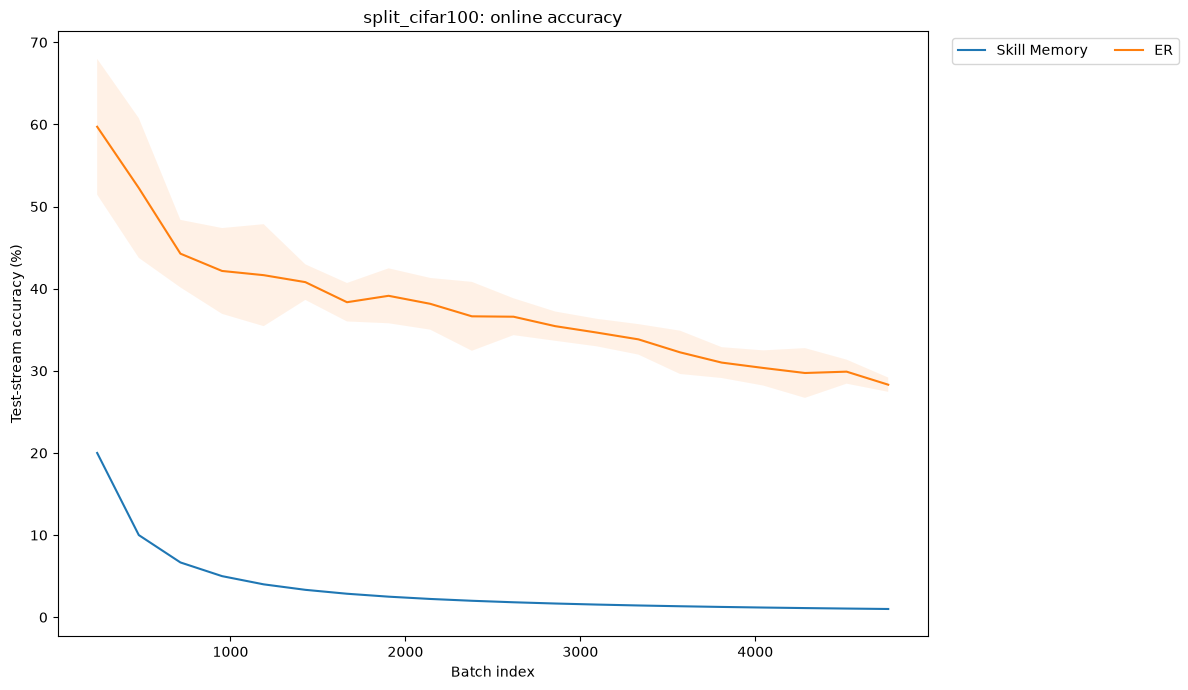

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))
for label, result in frames.items():
    df = result.get("training")
    if df is None or df.empty or TEST_STREAM not in df.columns:
        continue
    x = df[["seed", "mb_index", TEST_STREAM]].dropna().sort_values(["seed", "mb_index"])
    g = x.groupby("mb_index")[TEST_STREAM].agg(["mean", "std"]).reset_index()
    ax.plot(g["mb_index"], 100 * g["mean"], label=label)
    if len(g) > 1:
        std = g["std"].fillna(0)
        ax.fill_between(g["mb_index"], 100*(g["mean"]-std), 100*(g["mean"]+std), alpha=0.10)
ax.set(xlabel="Batch index", ylabel="Test-stream accuracy (%)", title=f"{BENCHMARK}: online accuracy")
ax.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout();
plt.savefig("accuracy_plot.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Causal catastrophic forgetting

This plot uses exactly the same `compute_average_forgetting` calculation as the scalar forgetting column above. Lower is better.


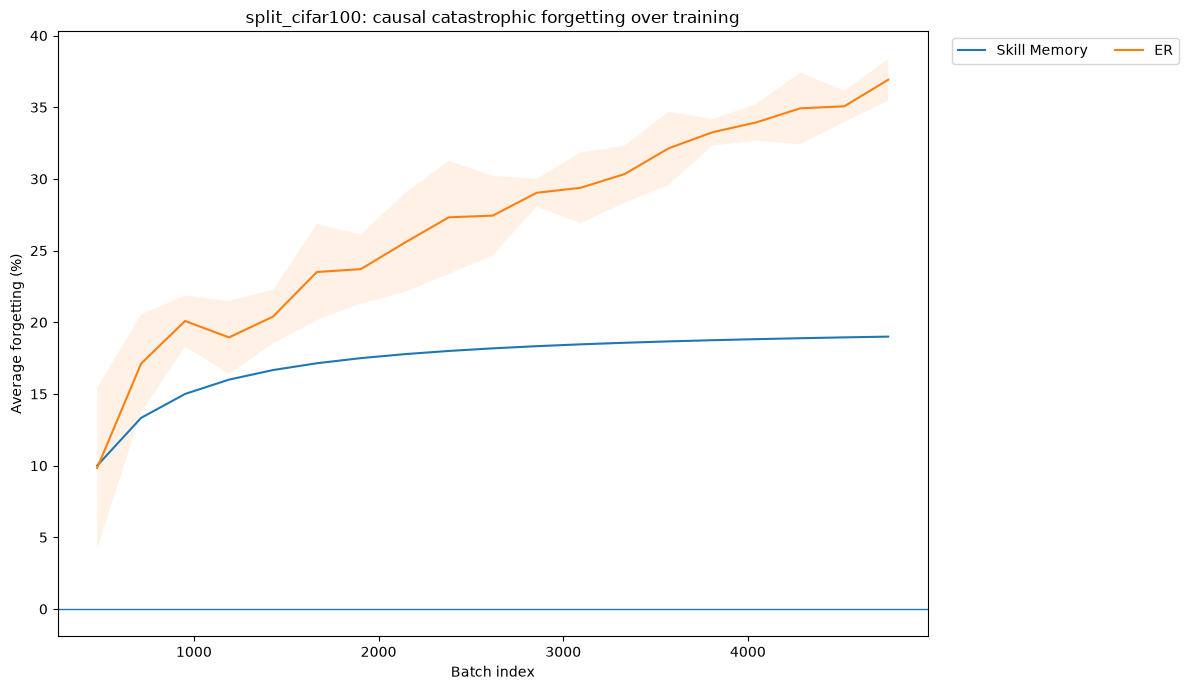

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))
for label, result in frames.items():
    df = result.get("training")
    if df is None or df.empty:
        continue
    required = [f"{TEST_EXP}{i:03d}" for i in range(NUM_TASKS)]
    if not set(required).issubset(df.columns):
        continue
    forgetting_df = compute_average_forgetting(df.copy(), NUM_TASKS)
    x = forgetting_df[["seed", "mb_index", "Average_Forgetting"]].dropna()
    if x.empty:
        continue
    g = x.groupby("mb_index")["Average_Forgetting"].agg(["mean", "std"]).reset_index()
    ax.plot(g["mb_index"], 100 * g["mean"], label=label)
    if len(g) > 1:
        std = g["std"].fillna(0)
        ax.fill_between(g["mb_index"], 100*(g["mean"]-std), 100*(g["mean"]+std), alpha=0.10)
ax.axhline(0, linewidth=1)
ax.set(xlabel="Batch index", ylabel="Average forgetting (%)", title=f"{BENCHMARK}: causal catastrophic forgetting over training")
ax.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout();
plt.savefig("forgetting_plot.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Save the comparison

The CSV is generated from the current result data; it is not used as an input to the comparison.


In [9]:
analysis_dir = RESULTS_ROOT / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)
summary_path = analysis_dir / "skill_memory_strategy_comparison.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Wrote {summary_path}")


Wrote /home/kobros-tech/workspace/AI/ocl_survey/results/analysis/skill_memory_strategy_comparison.csv
